In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import struct

# Get Dataset in DataFrame

In [2]:
PATH = '../dataset/resources/'

In [3]:
os.listdir(PATH)

['fuzz12.asc.xlsx',
 'Final Logs.7z',
 'Logging_Agent V3.7z',
 'host Udp dos.xlsx',
 'treerunner TCP scan.asc',
 'Final Logs',
 'Logging_Agent V3_Anamoly_Floading_Recovery.7z',
 'host Udp dos.zip',
 'Long logs_23_9_2019',
 'coll.ods',
 'Fuzzing-Log_LKA.xlsx']

In [4]:
a = pd.ExcelFile(PATH+'fuzz12.asc.xlsx')

In [5]:
dfs = {sheet_name: a.parse(sheet_name) 
          for sheet_name in a.sheet_names}

# Get Data in list

In [7]:
#normal_list = dfs.iloc[:,0]

In [7]:
#anml_list = list(dfs['CANOE'].iloc[:,0])
#recov_list = list(dfs['Logging_2'].iloc[:,0])
#long_list = list(dfs['PEN log'].iloc[:,0])
#udp_scan_list = list(dfs['host UDp scan'].iloc[:,0])
#tcp_scan_list = list(dfs['host tCP scan'].iloc[:,0])
#dos_list = list(dfs['host Udp dos'].iloc[:,0])# start of attack 21.020657 , end attack 23.322788 ,halting 21.188842
#can_fuz = list(dfs['Fuzzing-Log_LKA'].iloc[:,0])
lka_fuz_can = list(dfs['fuzz12'].iloc[:,0]) # We cut datasets at 51.000126 of index 203735 in the sheet

In [9]:
mother_list = lka_fuz_can

In [10]:
len(mother_list)

300521

# Invistigation

In [11]:
def invistigate(mother_list):
    sizes = [len(i.split()) for i in mother_list]
    a = np.array(sizes)
    for i in range(max(sizes)+1):
        if np.where(a == i)[0].shape[0] != 0:
            print(i,np.where(a == i)[0].shape[0])

In [12]:
invistigate(mother_list)

3 1
4 316
5 4
6 5
7 3
8 4
10 1
11 1
17 4290
18 7179
19 4140
20 4887
21 8784
22 8343
23 262563


In [18]:
l = []
for i in range(len(mother_list)):
    if len(mother_list[i].split()) == 23:
        l.append(i)

In [19]:
mother_list[l[3000]].split()

['0.880087',
 '1',
 '390',
 'Rx',
 'd',
 '8',
 '00',
 '00',
 '20',
 '00',
 '00',
 '00',
 '00',
 '00',
 'Length',
 '=',
 '241910',
 'BitCount',
 '=',
 '125',
 'ID',
 '=',
 '912']

In [15]:
def get_first(mother_list):
    
    for i in range(len(mother_list)):
        temp = mother_list[i].split()
        
        try:
            #if len(temp) >3 and temp[1] == 'CANFD' and temp[3]=='Tx' and (temp[4]=='0' or temp[4]=='1'):
            if temp[0] == '21.020657':
                return i
        except:
            pass

In [16]:
def get_last(mother_list):
    k=0
    for i in range(len(mother_list)-1,0,-1):
        temp = mother_list[i].split()
        try:
            #if len(temp) >3 and temp[1] == 'CANFD' and temp[3]=='Tx' and (temp[4]=='0' or temp[4]=='1'):
            if temp[0] == '23.322788' :
                return i
        except:
            pass
        

In [17]:
get_first(mother_list)

77637

In [18]:
get_last(mother_list)

181999

In [19]:
mother_list = mother_list[181999:]

In [19]:
len(mother_list)

519982

# Get All Valid Indices

In [20]:
def get_count(mother_list):
    all = []
    l = []
    for i in range(len(mother_list)):
        temp = mother_list[i].split()
        try:
            if len(temp) == 36:
                l.append(i)
            else:
                all.append(i)
        except:
            pass
            #print(temp)
    #print(c)
    return l

In [21]:
l = get_count(mother_list)

In [22]:
def get_all_indicies(mother_list):
    all = []
    for i in range(len(mother_list)):
        temp = mother_list[i].split()
        if (len(temp) not in [5,26,36]): # and temp :  or temp[2] == '2' or (temp[1] == 'ETH' and temp[3] == 'Tx') :
            pass
        else:
            all.append(i)
    return all

In [23]:
all = get_all_indicies(mother_list)

# Extract all

In [24]:
def get_all_types(all,mother_list):
    can = []
    ETH = []
    Long_ETH = []
    short_ETH = []
    
    for i in all:
        temp = mother_list[i].split()
        if 'CANFD' in temp[1] :
            can.append(i)
        else:
            ETH.append(i)
            if len(mother_list[i])>1500:
                Long_ETH.append(i)
            else:
                short_ETH.append(i)
    return can , ETH , Long_ETH , short_ETH

In [25]:
can , ETH , Long_ETH , short_ETH = get_all_types(all,mother_list)

In [26]:
mother_list[can[-10]]

'  72.348498 CANFD   1 Tx   ErrorFrame Not Acknowledge error, recessive error flag      fffe 47     11da Arb. 109      7df  1 1 8  8 02 3e 80 00 00 00 00 00   112015       17 f8000000 50280450 50280150 2003071e 2000071e'

In [27]:
mother_list[can[-11]].split()

['72.348352',
 'CANFD',
 '1',
 'Tx',
 'ErrorFrame',
 'Not',
 'Acknowledge',
 'error,',
 'recessive',
 'error',
 'flag',
 'fffe',
 '47',
 '11da',
 'Arb.',
 '109',
 '7df',
 '1',
 '1',
 '8',
 '8',
 '02',
 '3e',
 '80',
 '00',
 '00',
 '00',
 '00',
 '00',
 '112015',
 '17',
 'f8000000',
 '50280450',
 '50280150',
 '2003071e',
 '2000071e']

# Encode: Special for each dataset

In [28]:
def translate(l):
    j = []
    time_list = []
    time = 0.0
    for i in range(l.shape[0]):
        temp = l[i].replace('CANFD','0000') .replace('ETH','1111').replace('Rx','00').replace('Tx','11').replace(':',' ').split()
        if len(temp) == 6 :
            del temp[4]

        elif len(temp) in [26] :
            del temp[5]
          
        elif len(temp) in [36] :
            del temp[14]
            del temp[4:11]     
        else:
            j.append(i)
        t = temp[0]
        time_list.append(bin(struct.unpack('!i',struct.pack('!f',float(temp[0]) - time))[0])[2:])

        time = float(t)
        l[i] = ''.join(temp[1:])
    return l , j,time_list

In [29]:
rec_arr = np.array(mother_list)

In [30]:
all_,j,time = translate(rec_arr[all])

In [31]:
mother_list[all[500]]

'   0.537238 CANFD   1 Rx        459  TrailerAid_Stat3                 1 0 8  8 ff 00 32 0b 40 00 00 00   103031  135   323000 c800ee41 50280450 50280150 2003071e 2000071e'

In [32]:
all_[500]

'00001004591088ff00320b40000000103031135323000c800ee4150280450502801502003071e2000071e'

In [61]:
can,j = translate(rec_arr[can])

In [32]:
ETH,j = translate(rec_arr[ETH])

In [33]:
short_ETH,j = translate(rec_arr[short_ETH])

In [34]:
Long_ETH,j = translate(rec_arr[Long_ETH])

# Save

In [33]:
def hex_to_bin(hex_number):
    temp = len(hex_number)*4
    #print(hex_number)
    x = int(hex_number,16)
    y = np.array([int(i) for i in list(bin(x)[2:])])
    left_pad = temp-y.shape[0]
    
    return np.pad(y,(left_pad,0),'constant')

In [34]:
#bin_ETH
def binary_time_with_binary_representation(l,time):
    cat = []
    for i in range(len(l)):
        cat.append(hex_to_bin(hex(int(time[i],2))[2:] + l[i]))
    return cat

In [35]:
len(time),len(all_)

(469940, 469940)

In [38]:
#bin_ETH
def binary_time_with_binary_representation_store(l,time,path):
    cat = []
    for i in range(len(l)):
        temp = hex_to_bin(hex(int(time[i],2))[2:] + l[i])
        np.save(f'../dataset/{path}/imag_{i}.npy',temp)
    return cat

In [39]:
s = binary_time_with_binary_representation_store(all_,time,path)

In [58]:
#bin_ETH

def store_bin(l,path):
    c=0
    for i in range(len(l)):
        c+=1
        np.save(f'../dataset/{path}/imag_{i}.npy',hex_to_bin(l[i]))
    print(c)


"\ndef store(l,path):\n    c=0\n    for i in range(len(l)):\n        c+=1\n        np.save(f'../dataset/{path}/imag_{i}.npy',hex_to_bin(l[i]))\n    print(c)\n"

In [39]:
#without binarying
def store(l,path):
    c=0
    for i in range(len(l)):
        c+=1
        np.save(f'../dataset/{path}/imag_{i}.npy',l[i])
    print(c) 


In [37]:
path = 'fuz attack/complete/all/bin/'

In [41]:
len(all)

336902

In [42]:
store(s,f'{path}/bin')

336902


In [38]:
store(can,f'{path}/CAN')

52053


In [153]:
store(ETH,f'{path}/ETH')

8620


In [154]:
store(short_ETH,f'{path}/ETH_short')

6754


In [155]:
store(Long_ETH,f'{path}/ETH_long')

1866


## Convert messages to hex representation per pixel

In [24]:
all = [mother_list[i].lower() for i in all]

In [25]:
rec_arr = np.array(all)

In [26]:
def translate(l):
    for i in range(l.shape[0]):
        temp = l[i].replace('canfd','0000') .replace('eth','1111').replace('rx','00').replace('tx','11').replace(':',' ').split()
        l[i] = ''.join(temp[1:])
    return l 

In [27]:
all = translate(rec_arr)

In [28]:
all[2]

'111110013a02f052440022106530e6f13108004500012cea8900b940117a720a0200060a020003511d7c67ad5dccc8887dd800abc875a28d1f0e708a11bfc9384ae67695490740b87dc9b999785a714400316e1a5f7194157e9648dd2e8491b3ea5e7e5669ce2fb26d8ca8ff1a58b81f8dc2de0f423b76790b19b4ee9b0c851bd82c2cd034bdf957316c535f96feee6e7c1def9e2eaa1b19126a5efd01d24344ea43ab40eb03b9f424c0bbdb99bd3967ec2d18df04818efe4c43d6013a721eea1fddd4604366d5d8897a810a040584af7760cdb093cc4dbe180aaa081760b26857d1b304bd98e6c0998b8f6f844ee1938056969a8a64cc63aa90cff12f0b14549dc711008ae316345dbb7cec37ead1c13ed93b2da2597cc54eb98315d04cfeef0b8671b79eac4aab95d9aa58867cfa824f0e633d9040e1c88dbd72ea4b8a0d'

In [29]:
def get_dicts(mother_list):    
    all = []
    for i in mother_list:
        all += i
    elements = sorted(list(set(all)))
    stoi = {i:v for v,i in enumerate(elements)}
    itos = {i:v for i,v in enumerate(elements)}
    return stoi , itos

In [30]:
stoi , itos = get_dicts(all)

In [31]:
len(all[0])

261

In [32]:
hex_message = [[stoi[i] for i in j ] for j in all]

In [33]:
sizes = [len(i) for i in hex_message]

In [34]:
max(sizes)

3038

In [82]:
len(hex_message)

46096

In [78]:
len(hex_message[0])

261

In [83]:
import matplotlib.pyplot

(array([1.6000e+01, 4.0294e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 5.7860e+03]),
 array([ 251. ,  529.7,  808.4, 1087.1, 1365.8, 1644.5, 1923.2, 2201.9,
        2480.6, 2759.3, 3038. ]),
 <a list of 10 Patch objects>)

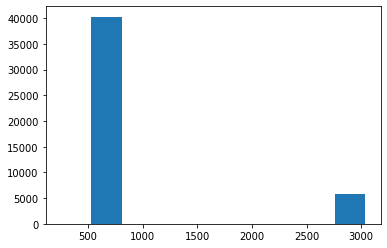

In [84]:
plt.hist(sizes)

In [43]:
def store(l,path):
    for i in range(len(l)):
        np.save(f'dataset/{path}/imag_{i}.npy',l[i])

In [44]:
store(hex_message,'anml/hex')